# 分岐現象の観察

このノートでは，いくつかの写像に対して力学系の分岐現象を観察する．

## logistic 写像の分岐現象

ロジスティック写像: $F_a(x) = ax(1-x) $ の定める力学系の振る舞いが $a$ を変化させたときにどのように変化するかを観察する．実際に行う実験は以下の通り．

- 初期値 $x_0 \in [0,1] $ を選ぶ
- メッシュした $a \in [a_{\min}, a_{\max}]$ の各点に対し，$(a,x)$ 平面に次の点をプロット
    $$ \{(a, F_a^n(x_0)) | n_{\text{burn}} \le n < n_{\text{burn}} + n_{\text{iter}} \}$$

例えば，$F_{a_0}$ に対し，$x_0$ からスタートする軌道が固定点に収束していくならば，$n_{\text{iter}}$ が十分大きければ $(a_0, F_{a_0}^n(x_0)), n_{\text{burn}} \le n < n_{\text{burn}} + n_{\text{iter}}$ という点たちはすべてほぼ同じ点に見えるはずで，可視化の上では $a = a_0$ という直線上にある点は1点に見えるはずである．同様に，周期 $2$ の周期点に収束していくならば，$a = a_0$ という直線上にある点は2点に見えるはずである．
このように，$a=a_0$ 上にプロットされている点の様子を見て，軌道の振る舞いを観察でき，振る舞いが $a$ を変えるにしたがってどう変化するかを見ようとしている．

※ 添え字 burn, iter はそれぞれ burn-in, iterationsを意図している．

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja

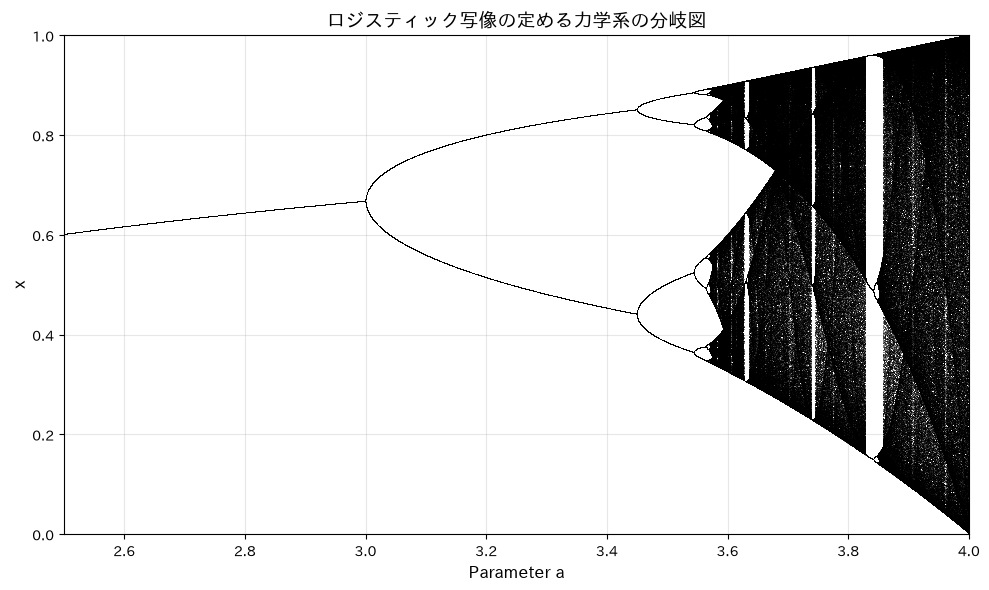

In [2]:
a_min, a_max = 2.5, 4.0 # 考慮するaの範囲
num_a = 10000  # 点の数
num_burn = 3000
num_iter = 300

x0 = 0.5 # 初期値
a_values = np.linspace(a_min, a_max, num_a)

bifurcation_a = []
bifurcation_x = []

for a in a_values:
    x = x0
    
    # 極限的なふるまいを見るために始めの軌道を捨てる
    for _ in range(num_burn):
        x = a * x * (1 - x)
    #  
    for _ in range(num_iter):
        x = a * x * (1 - x)
        bifurcation_a.append(a)
        bifurcation_x.append(x)

# 分岐図をプロット
plt.figure(figsize=(10, 6))
plt.plot(bifurcation_a, bifurcation_x, ',k', markersize=0.3, alpha=0.5)
plt.xlabel('Parameter a', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('ロジスティック写像の定める力学系の分岐図', fontsize=14)
plt.xlim(a_min, a_max)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../out/bifurcation_diagram_logistic.png', dpi=300)
plt.show()

## 勾配降下法に対する分岐の実験

上記のロジックは `src/gd_and_chaos` に共通関数としてまとめてあるため，関数を呼び出せば様々な関数に対して分岐の実験を実行できる．ここでは，4次多項式 $f(x) = (x^2 - 1)^2$ に対する勾配降下法の写像 $F_\eta (x) = x - \eta f'(x) = -4\eta x^3 + (4\eta + 1) x$ について分岐を観察する．

In [3]:
from gd_and_chaos import BifurcationExperimentConfig, run_bifurcation_experiment, plot_bifurcation_diagram

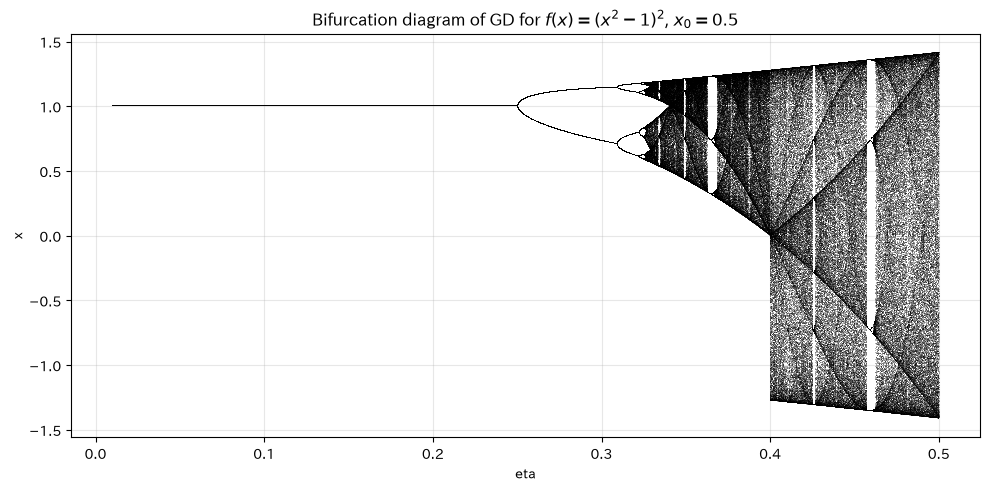

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Bifurcation diagram of GD for $f(x)=(x^2-1)^2$, $x_0=0.5$'}, xlabel='eta', ylabel='x'>)

In [4]:
def gd_map(x, eta):
    return -4 * eta * x ** 3 + (4 * eta + 1) * x


config = BifurcationExperimentConfig(
    parameter_values= np.linspace(0.01, 0.6, 5000),  # パラメータの範囲と分割数
    parameter_name="eta",   # パラメータの名前
    x0=0.5,   # 初期値
    n_burn=1000,   # 軌道を捨てるステップ数
    n_iter=200,   # 軌道を記録するステップ数
)
bifurcation_a, bifurcation_x = run_bifurcation_experiment(gd_map, config)
plot_bifurcation_diagram(bifurcation_a, bifurcation_x, config, 
                         title=f"Bifurcation diagram of GD for $f(x)=(x^2-1)^2$, $x_0={config.x0[0]}$")

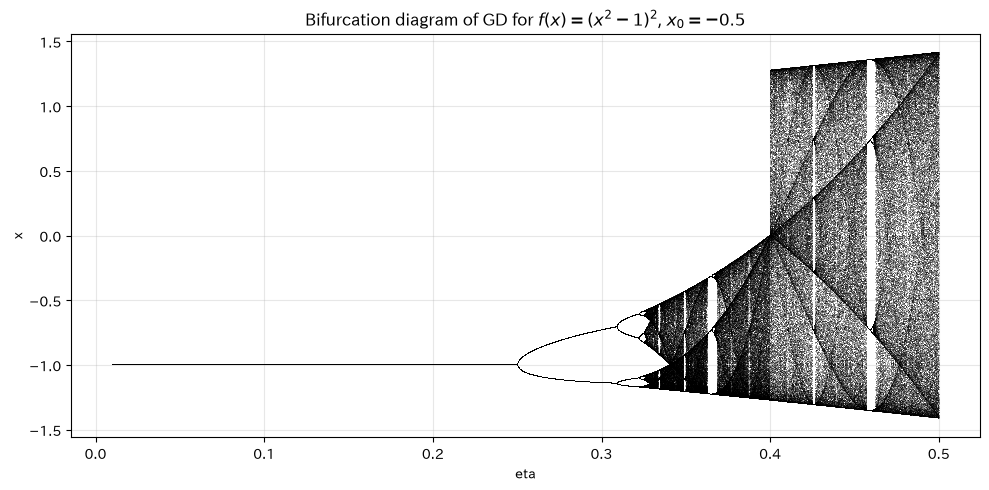

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Bifurcation diagram of GD for $f(x)=(x^2-1)^2$, $x_0=-0.5$'}, xlabel='eta', ylabel='x'>)

In [5]:
config = BifurcationExperimentConfig(
    parameter_values= np.linspace(0.01, 0.6, 5000),  # パラメータの範囲と分割数
    parameter_name="eta",   # パラメータの名前
    x0=-0.5,   # 初期値
    n_burn=1000,   # 軌道を捨てるステップ数
    n_iter=200,   # 軌道を記録するステップ数
)
bifurcation_a, bifurcation_x = run_bifurcation_experiment(gd_map, config)
plot_bifurcation_diagram(bifurcation_a, bifurcation_x, config, 
                         title=f"Bifurcation diagram of GD for $f(x)=(x^2-1)^2$, $x_0={config.x0[0]}$")

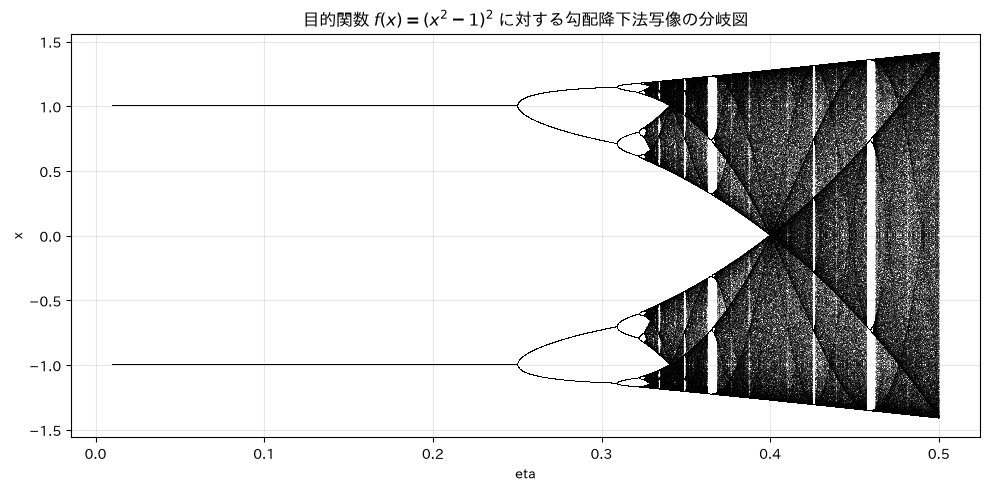

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': '目的関数 $f(x)=(x^2-1)^2$ に対する勾配降下法写像の分岐図'}, xlabel='eta', ylabel='x'>)

In [6]:
config = BifurcationExperimentConfig(
    parameter_values= np.linspace(0.01, 0.6, 5000),  # パラメータの範囲と分割数
    parameter_name="eta",   # パラメータの名前
    x0=[0.5, -0.5],   # 初期値
    n_burn=1000,   # 軌道を捨てるステップ数
    n_iter=200,   # 軌道を記録するステップ数
)
bifurcation_a, bifurcation_x = run_bifurcation_experiment(gd_map, config)
plot_bifurcation_diagram(bifurcation_a, bifurcation_x, config, 
                         title=f"目的関数 $f(x)=(x^2-1)^2$ に対する勾配降下法写像の分岐図",
                         save=True,
                         save_path="../out/bifurcation_diagram_gd_map.png",
                         )